# Netflix Movies and TV Shows — Exploratory Data Analysis

## Project Overview
Exploratory Data Analysis of the Netflix Movies and TV Shows dataset using Python, Pandas, NumPy, Matplotlib and Seaborn.


## 1. Import Libraries


In [39]:
import numpy as numpy
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

## 2. Load Dataset


In [40]:
df = pd.read_csv('netflix_titles.csv')

## 3. Data Understanding
Inspect the dataset structure, dimensions, columns, data types and summary statistics.


In [41]:
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [42]:
df.tail(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [43]:
df.shape

(8807, 12)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [45]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


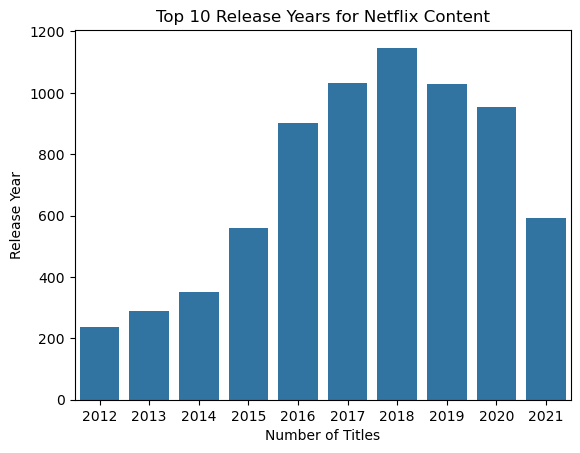

In [46]:
top_years = df["release_year"].value_counts().head(10)

sns.barplot(x=top_years.index, y=top_years.values)

plt.title("Top 10 Release Years for Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Release Year")
plt.show()

In [47]:
top_years.head(10)

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64

In [48]:
df.select_dtypes(include="number").columns

Index(['release_year'], dtype='object')

In [49]:
numeric_df = df.select_dtypes(include="number")

numeric_df.corr()

,release_year
release_year,1.0


## 4. Data Cleaning

### 4.1 Missing Values
First identify missing values, then handle them appropriately.


In [50]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [51]:
df.isnull().mean()*100

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

In [52]:
# Replace missing values in descriptive text/categorical columns.
# 'Unknown' preserves the row while making the missing state explicit.
for col in ['director', 'cast', 'country', 'rating', 'duration']:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')


### 4.2 Convert `date_added` to Datetime


In [53]:
if 'date_added' in df.columns:
    df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')


### 4.3 Remove Duplicate Rows


In [54]:
print(df.duplicated().sum())

0


In [55]:
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates().copy()
print("Duplicates after:", df.duplicated().sum())


Duplicates before: 0
Duplicates after: 0


### 4.4 Verify Cleaned Data


In [56]:
print("Shape after cleaning:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum().sort_values(ascending=False))
df.head()


Shape after cleaning: (8807, 12)

Missing values after cleaning:
date_added      98
show_id          0
type             0
title            0
director         0
cast             0
country          0
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 5. Univariate Analysis


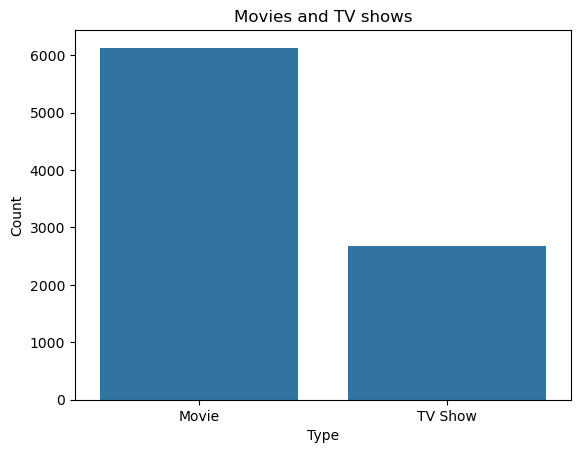

In [57]:
sns.countplot(data=df , x = "type")

plt.title("Movies and TV shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

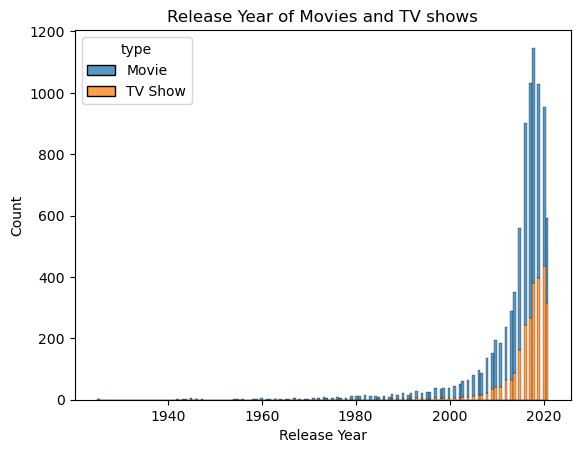

In [58]:
sns.histplot(data=df , x = "release_year" , hue = "type" , multiple = "stack")

plt.title("Release Year of Movies and TV shows")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.show()

plt.show()

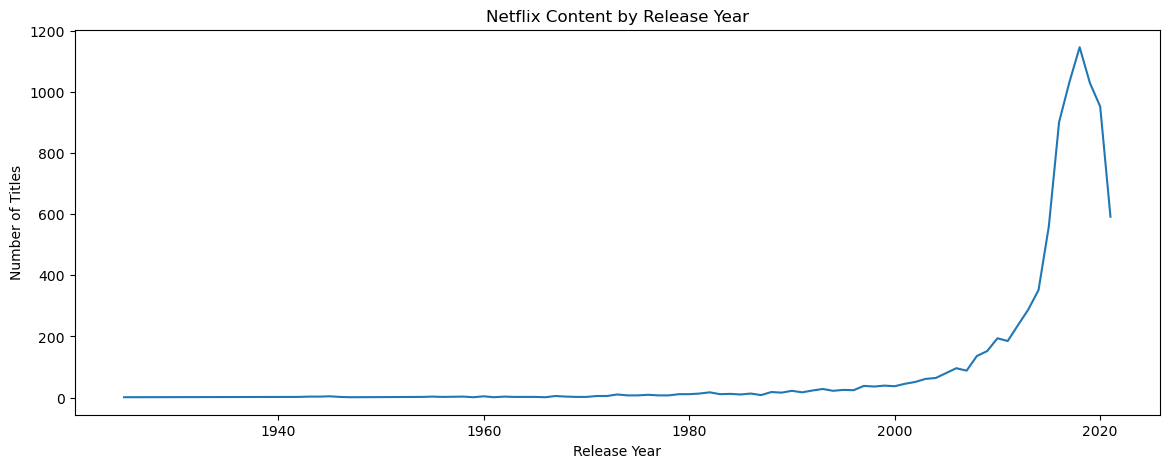

In [59]:
year_counts = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(14,5))

plt.plot(year_counts.index, year_counts.values)

plt.title("Netflix Content by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

In [60]:
df["rating"].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
Unknown        4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

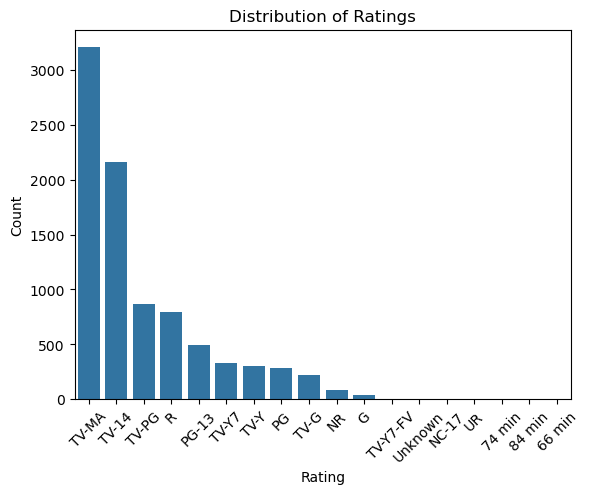

In [61]:
sns.countplot(data=df, x='rating' , order=df['rating'].value_counts().index) 

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

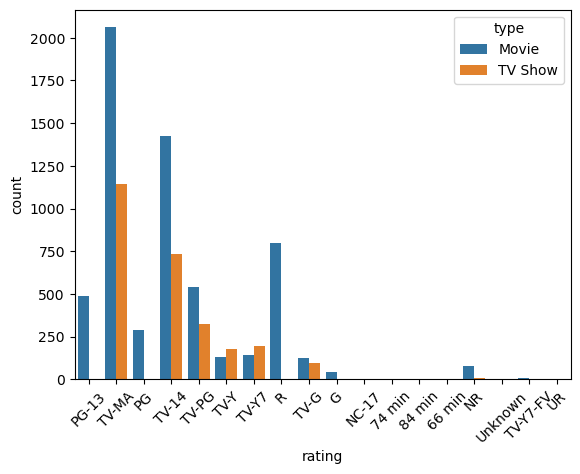

In [62]:
sns.countplot(data=df, x="rating", hue="type")
plt.xticks(rotation=45)
plt.show()

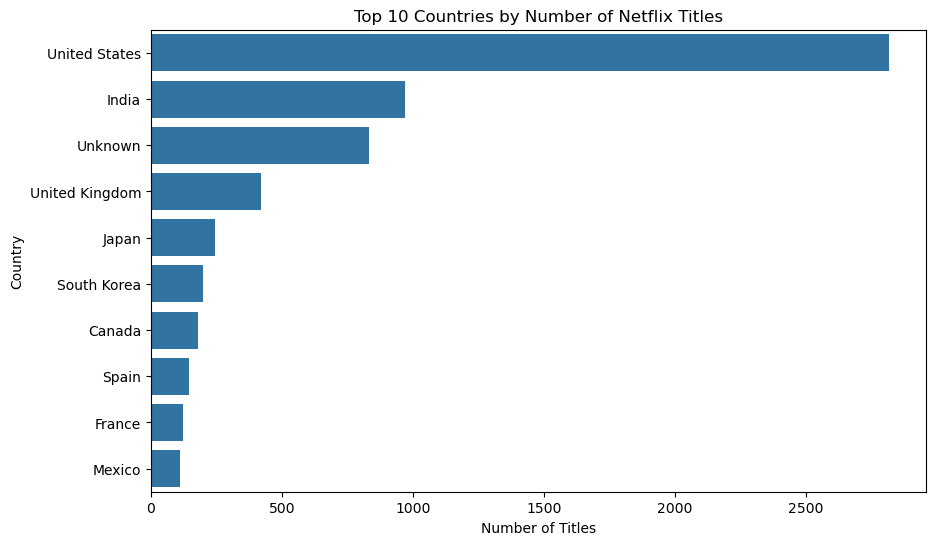

In [63]:
plt.figure(figsize=(10, 6))

sns.countplot(
    y="country",
    data=df,
    order=df["country"].value_counts().iloc[:10].index
)

plt.title("Top 10 Countries by Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

In [64]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df['added_year'] = df['date_added'].dt.year

added_year = df['added_year'].value_counts().sort_index()
print(added_year)



added_year
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64


## 6. Bivariate Analysis


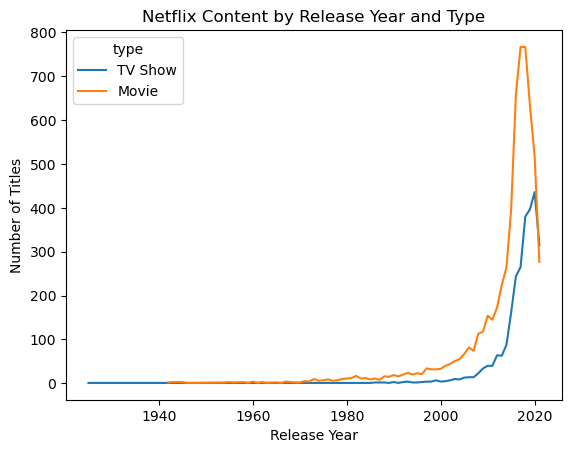

In [65]:
year_type = df.groupby(["release_year", "type"]).size().reset_index(name="count")

sns.lineplot(
    data=year_type,
    x="release_year",
    y="count",
    hue="type"
)

plt.title("Netflix Content by Release Year and Type")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

In [66]:
year_type = (
    df.groupby(["release_year", "type"])
      .size()
      .reset_index(name="count")
)

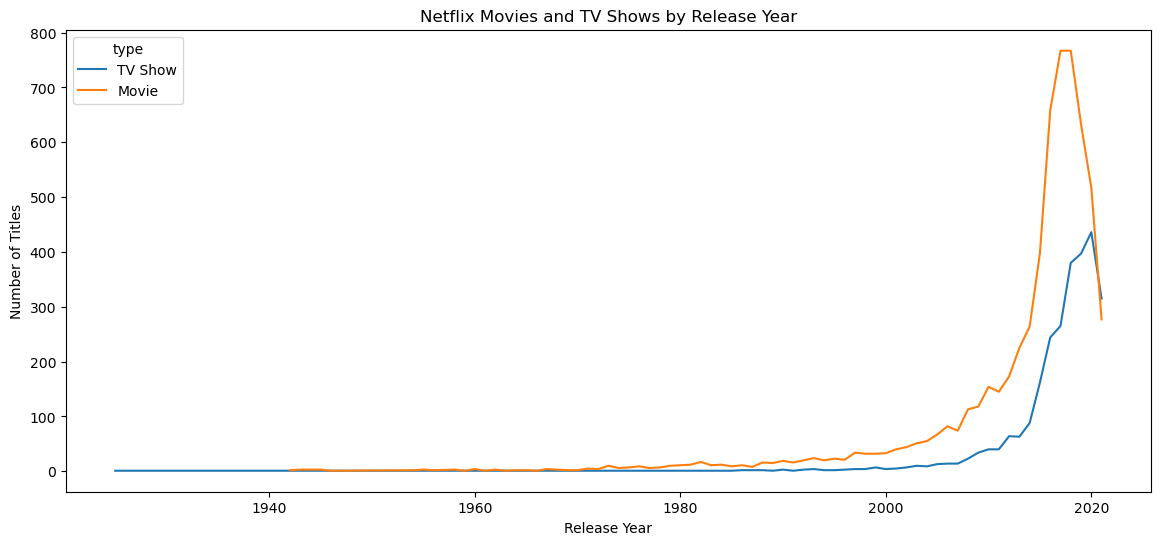

In [67]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=year_type,
    x="release_year",
    y="count",
    hue="type"
)

plt.title("Netflix Movies and TV Shows by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

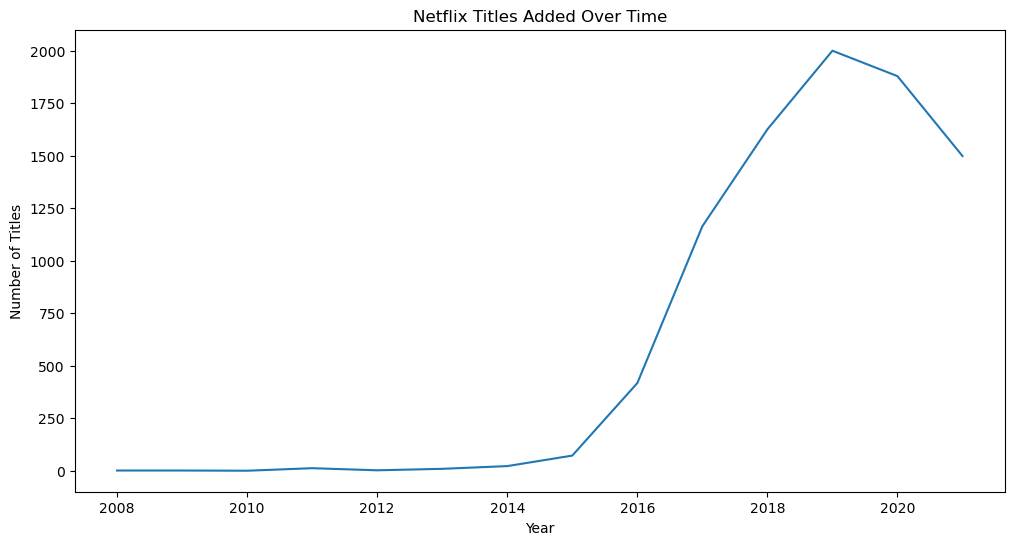

In [68]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=added_year.index,
    y=added_year.values
)

plt.title("Netflix Titles Added Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

## 7. Multivariate Analysis


<Axes: >

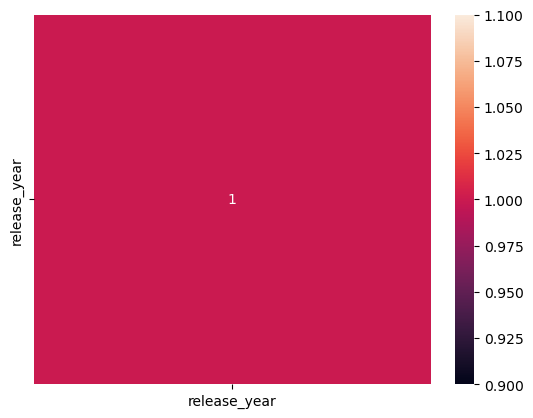

In [69]:
sns.heatmap(numeric_df.corr() , annot = True)

In [74]:
movies = df[df['type'] == 'Movie'].copy()

movies['duration_min'] = movies['duration'].str.extract(r'(\d+)').astype(float)

movies['duration_min'].describe()

count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_min, dtype: float64